In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/pothole detection model/Pothole Classification.folder.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Done!")


Done!


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [5]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
ds_path ='/content/dataset/train'
img_size = (224, 224)
batch_size = 32
seed = 42

In [7]:
import os
from PIL import Image

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.gif')

def deep_clean(folder_path):
    removed = 0
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)

            # Remove files that aren't images by extension
            if not file.lower().endswith(VALID_EXTENSIONS):
                print(f"Removing non-image: {file_path}")
                os.remove(file_path)
                removed += 1
                continue

            # Try to open and verify
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception as e:
                print(f"Removing corrupt: {file_path}")
                os.remove(file_path)
                removed += 1

    print(f"\nDone! Removed {removed} files.")

deep_clean('/content/dataset/train')


Done! Removed 0 files.


In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    ds_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size

)

val_ds = tf.keras.utils.image_dataset_from_directory(
    ds_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes found:", class_names)
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())

Found 13063 files belonging to 2 classes.
Using 10451 files for training.
Found 13063 files belonging to 2 classes.
Using 2612 files for validation.
Classes found: ['Not Pothole', 'Pothole']
Train batches: 327
Val batches: 82


In [9]:
val_batches = tf.data.experimental.cardinality(val_ds)

test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Val batches: 41
Test batches: 41


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.2),
], name="augmentation")

In [12]:
normalization = layers.Rescaling(1./255)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                          include_top=False,
                          weights='imagenet')
base_model.trainable = False


inputs = tf.keras.Input(shape=(224, 224, 3))
x = augmentation(inputs)
x = normalization(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.2, patience=2, monitor='val_loss')
]

# Apply ignore_errors to datasets to skip problematic files
train_ds = train_ds.ignore_errors()
val_ds = val_ds.ignore_errors()

print("Phase 1:Training classification head")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Phase 1:Training classification head
Epoch 1/10
    323/Unknown 66s 58ms/step - accuracy: 0.8392 - loss: 0.3737

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


323/323 ━━━━━━━━━━━━━━━━━━━━ 78s 93ms/step - accuracy: 0.8544 - loss: 0.3359 - val_accuracy: 0.8969 - val_loss: 0.2612 - learning_rate: 0.0010
Epoch 2/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.8773 - loss: 0.2947 - val_accuracy: 0.9023 - val_loss: 0.2559 - learning_rate: 0.0010
Epoch 3/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8839 - loss: 0.2758 - val_accuracy: 0.9015 - val_loss: 0.2479 - learning_rate: 0.0010
Epoch 4/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.8829 - loss: 0.2691 - val_accuracy: 0.8969 - val_loss: 0.2385 - learning_rate: 0.0010
Epoch 5/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8948 - loss: 0.2516 - val_accuracy: 0.8992 - val_loss: 0.2380 - learning_rate: 0.0010
Epoch 6/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.8969 - loss: 0.2545 - val_accuracy: 0.9077 - val_loss: 0.2228 - learning_rate: 0.0010
Epoch 7/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.8993 - loss: 0.2427

In [14]:

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Phase 2: Fine-tuning top layers")
history2 = model.fit(
    train_ds.repeat(),
    validation_data=val_ds.repeat(),
    epochs=10,
    steps_per_epoch=323,
    validation_steps=40,
    callbacks=callbacks
)

Phase 2: Fine-tuning top layers
Epoch 1/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.8832 - loss: 0.2813 - val_accuracy: 0.9047 - val_loss: 0.2240 - learning_rate: 1.0000e-05
Epoch 2/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.8997 - loss: 0.2498 - val_accuracy: 0.9078 - val_loss: 0.2241 - learning_rate: 1.0000e-05
Epoch 3/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 26s 81ms/step - accuracy: 0.9017 - loss: 0.2370 - val_accuracy: 0.9109 - val_loss: 0.2189 - learning_rate: 2.0000e-06
Epoch 4/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 27s 83ms/step - accuracy: 0.9042 - loss: 0.2357 - val_accuracy: 0.9086 - val_loss: 0.2169 - learning_rate: 2.0000e-06


In [16]:
##loading best model
model = tf.keras.models.load_model('best_model.keras')


print("\nFinal Test Set Evaluation")
loss, accuracy = model.evaluate(test_ds.repeat(), steps=40)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")


Final Test Set Evaluation
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9133 - loss: 0.2158

Test Accuracy: 91.33%
Test Loss: 0.2158


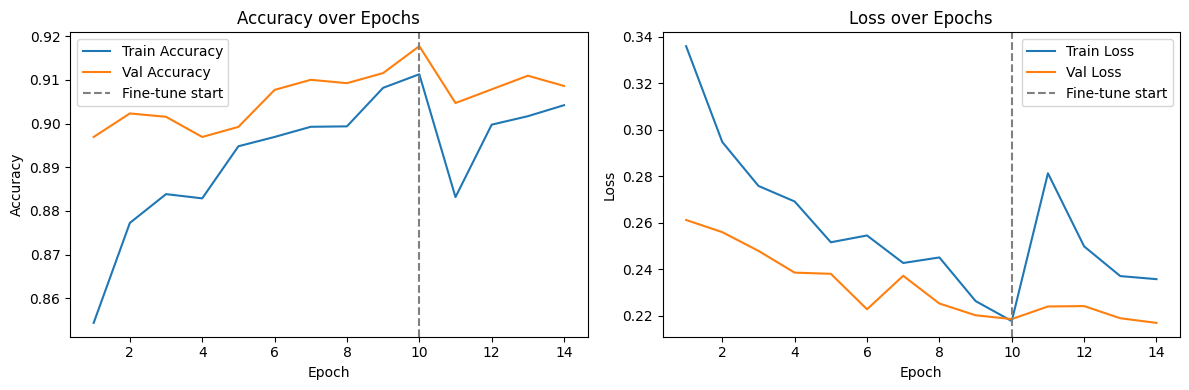

In [17]:
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Val Accuracy')
    plt.axvline(x=10, color='gray', linestyle='--', label='Fine-tune start')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.axvline(x=10, color='gray', linestyle='--', label='Fine-tune start')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

plot_history(history1, history2)

In [19]:
## saving model
model.save('pothole_model_final.keras')
###downloading model
from google.colab import files
files.download('best_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>